# Neural Network Training


## Softmax Function

In [1]:
import numpy as np

In [4]:
# softmax version 1
def softmax(x):
    """Compute the softmax of vector x."""
    e_x = np.exp(x)
    #return e_x / e_x.sum()
    s_x = np.sum(e_x)
    return e_x / s_x

In [5]:
# test the softmax function
x = np.array([1.0, 2.0, 3.0])
print(softmax(x))

[0.09003057 0.24472847 0.66524096]


In [7]:
# test the softmax function with a big number
x = np.array([1.0, 2.0, 900])
print(softmax(x))

[ 0.  0. nan]


/tmp/ipykernel_18754/2713309464.py:4: RuntimeWarning: overflow encountered in exp
  e_x = np.exp(x)
/tmp/ipykernel_18754/2713309464.py:7: RuntimeWarning: invalid value encountered in divide
  return e_x / s_x


In [8]:
# softmax version 2 (numerically stable)
def softmax_stable(x):
    """Compute the softmax of vector x in a numerically stable way."""
    c = np.max(x)
    e_x = np.exp(x - c)
    s_x = np.sum(e_x)
    return e_x / s_x

In [11]:
# test this new softmax function with origial same values   
x = np.array([1.0, 2.0, 3.0])
print(softmax_stable(x))

[0.09003057 0.24472847 0.66524096]


In [10]:
# test the softmax function with a larger value 
x = np.array([1.0, 2.0, 900])
print(softmax_stable(x))

[0. 0. 1.]


# This is preparation for MnistData class

## Download Mnist Dataset

In [12]:
mnist_files = {
    'x_train': 'train-images-idx3-ubyte.gz',
    'y_train': 'train-labels-idx1-ubyte.gz',
    'x_test': 't10k-images-idx3-ubyte.gz',
    'y_test': 't10k-labels-idx1-ubyte.gz'
}


In [13]:
def download_mnist_data():
    import os
    import urllib.request
    import gzip

    base_url = 'http://jrkwon.com/data/ece5831/mnist/'

    # To avoid 406 Not Acceptable error, we need to set the User-Agent header
    opener = urllib.request.build_opener()
    opener.addheaders = [('Accept', '')]
    urllib.request.install_opener(opener)

    for key, filename in mnist_files.items():
        url = base_url + filename
        # if the file already exists, skip downloading
        if os.path.exists(filename):
            print(f'{filename} already exists, skipping download.')
            continue
        print(f'Downloading {filename}...')
        urllib.request.urlretrieve(url, filename)
        print(f'{filename} downloaded.')

In [14]:
# test the download function
download_mnist_data()

train-images-idx3-ubyte.gz already exists, skipping download.
train-labels-idx1-ubyte.gz already exists, skipping download.
t10k-images-idx3-ubyte.gz already exists, skipping download.
t10k-labels-idx1-ubyte.gz already exists, skipping download.


## Prepare Mnist Data to Return

In [20]:
mnist_data = {
    "x_train": None,
    "y_train": None,
    "x_test": None,
    "y_test": None
}

def load_mnist_images(filename): 
    import gzip
    import numpy as np

    with gzip.open(filename, 'rb') as f:
        # The first 16 bytes are header information, so we skip them
        data = np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28*28)
    return data

def load_mnist_labels(filename):
    import gzip
    import numpy as np

    with gzip.open(filename, 'rb') as f:
        # The first 8 bytes are header information, so we skip them
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

def load_mnist_data():
    import gzip
    import numpy as np

    for key, filename in mnist_files.items():
        if 'x_' in key:
            mnist_data[key] = load_mnist_images(filename)
        elif 'y_' in key:
            mnist_data[key] = load_mnist_labels(filename)
        else:
            raise ValueError(f'Unknown file type: {filename}')
        
    (x_train, y_train), (x_test, y_test) = (mnist_data['x_train'], mnist_data['y_train']), (mnist_data['x_test'], mnist_data['y_test'])
    return (x_train, y_train), (x_test, y_test)


In [22]:
# test the load function
(x_train, y_train), (x_test, y_test) = load_mnist_data()

# keep this if the mnist_data dictionary has the loaded data
print("mnist_data dictionary:")
print(mnist_data['x_train'].shape)  # should be (60000, 784)
print(mnist_data['y_train'].shape)  # should be (60000,)
print(mnist_data['x_test'].shape)   # should be (10000, 784)
print(mnist_data['y_test'].shape)   # should be (10000,)

# print x_train and y_train to check if they are loaded correctly
print("return values of load_mnist_data function:")
print(x_train.shape)  # should be (60000, 784)
print(y_train.shape)  # should be (60000,)
print(x_test.shape)   # should be (10000, 784)
print(y_test.shape)   # should be (10000,)

mnist_data dictionary:
(60000, 784)
(60000,)
(10000, 784)
(10000,)
return values of load_mnist_data function:
(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [23]:
# test the load function with a random index
import random

# test the train data with a random index
num = random.randint(0, x_train.shape[0] - 1)
print(f'Random index: {num}')

print(f'y_train[{num}]: {y_train[num]}')  # should be a number between 0 and 9



Random index: 28378
y_train[28378]: 1


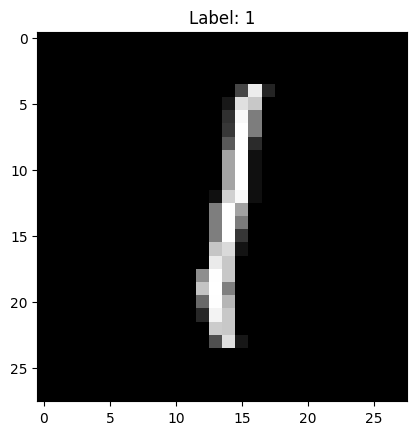

In [25]:
# plot the image corresponding to the random index
import matplotlib.pyplot as plt

plt.imshow(x_train[num].reshape(28, 28), cmap='gray')
plt.title(f'Label: {y_train[num]}')
plt.show()

In [27]:
# Test the test data with a random index
num = random.randint(0, x_test.shape[0] - 1)
print(f'Random index: {num}')   
print(f'y_test[{num}]: {y_test[num]}')  # should be a number between 0 and 9

Random index: 7075
y_test[7075]: 3


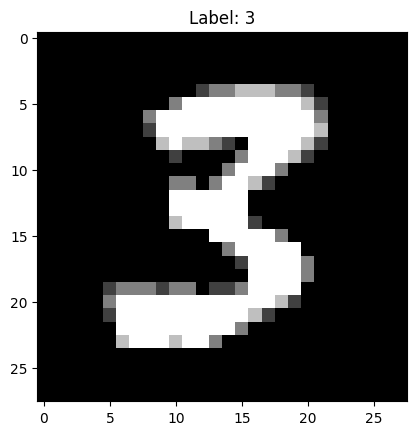

In [29]:
# plot the image corresponding to the random index
plt.imshow(x_test[num].reshape(28, 28), cmap='gray')
plt.title(f'Label: {y_test[num]}')
plt.show()